<a href="https://colab.research.google.com/github/Nourin-Nusrat/CSE4261_DNN/blob/main/Assignment9/DNN_Assignment_9_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library Import

In [ ]:

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


#Load CIFAR-10 with Normalized Tensor

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

#Denoising Autoencoder

In [1]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),  # 32x16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 64x8x8
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # 128x4x4
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  # 64x8x8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # 32x16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),   # 3x32x32
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

#Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#Add Gaussian Noise
def add_noise(imgs, noise_level=0.2):
    noisy = imgs + noise_level * torch.randn_like(imgs)
    return torch.clip(noisy, 0., 1.)

#Training Loop
print("Training denoising autoencoder...")
for epoch in range(10):
    total_loss = 0
    for clean_imgs, _ in train_loader:
        clean_imgs = clean_imgs.to(device)
        noisy_imgs = add_noise(clean_imgs)

        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}: Loss = {total_loss / len(train_loader):.4f}")


100%|██████████| 170M/170M [00:23<00:00, 7.12MB/s]


Training denoising autoencoder...
Epoch 1: Loss = 0.0183
Epoch 2: Loss = 0.0089
Epoch 3: Loss = 0.0073
Epoch 4: Loss = 0.0067
Epoch 5: Loss = 0.0063
Epoch 6: Loss = 0.0058
Epoch 7: Loss = 0.0054
Epoch 8: Loss = 0.0052
Epoch 9: Loss = 0.0051
Epoch 10: Loss = 0.0050


#Visualize Clean vs Noisy vs Denoised

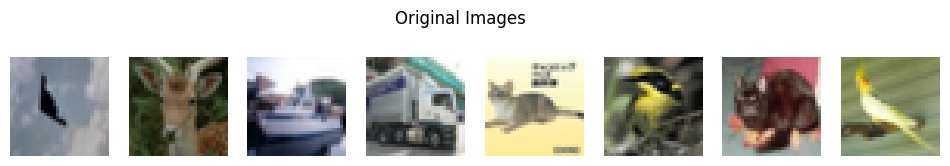

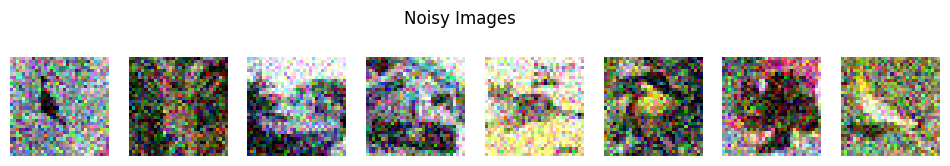

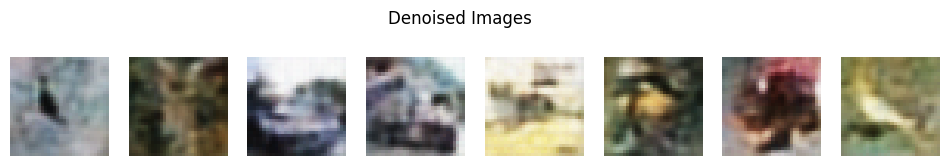

In [2]:
model.eval()
examples = next(iter(train_loader))[0][:4].to(device)
noisy_examples = add_noise(examples)

with torch.no_grad():
    denoised = model(noisy_examples)

def show_images(images, title):
    images = images.cpu().numpy().transpose(0, 2, 3, 1)
    fig, axes = plt.subplots(1, len(images), figsize=(12, 2))
    fig.suptitle(title)
    for i, img in enumerate(images):
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.show()

show_images(examples, "Original Images")
show_images(noisy_examples, "Noisy Images")
show_images(denoised, "Denoised Images")
